<a href="https://colab.research.google.com/github/VakeesanM/GPT1-Paper-Implementation/blob/main/GPT/training/model_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer
from datasets import load_dataset
import time
import matplotlib.pyplot as plt
import sys

In [ ]:
!git clone https://github.com/VakeesanM/GPT1-Paper-Implementation.git

Cloning into 'GPT1-Paper-Implementation'...
remote: Enumerating objects: 115, done.
remote: Counting objects: 100% (115/115), done.
remote: Compressing objects: 100% (78/78), done.
remote: Total 115 (delta 57), reused 88 (delta 31), pack-reused 0 (from 0)
Receiving objects: 100% (115/115), 163.32 KiB | 1.29 MiB/s, done.
Resolving deltas: 100% (57/57), done.


In [ ]:
sys.path.append("/content/GPT1-Paper-Implementation/GPT")

In [ ]:
from components.transformer import Transformer
from training.streamer import Streamer

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
CONTEXT_LEN = 128 # How many tokens the Model can look at once
EMBED_DIM = 300 # The Dimension of Vector Embeddings. GPT1 Actually used 768, but for performance reasons, I have decided to reduce it.
ATTN_HEAD = 12 # The Amount of Attention Heads at Mask Multi Head and Normal Multi Head Attention in each decoder.
# IMPORTANT: EMBED_DIM must be DIVISIBLE by ATTN_HEAD with no remainders.
DECODER_BLOCKS = 12 # The amount of Decoder Blocks in the Model.
TRAINING_EPOCHS = 15 # The Number of Epochs the Model will be trained for

#Loading and Processing Data

In [ ]:
ds = load_dataset("roneneldan/TinyStories", split="train[:12000]")

README.md:   0%|          | 0.00/1.06k [00:00<?, ?B/s]

data/train-00000-of-00004-2d5a1467fff108(…): reconstructing file:   0%|          |  0.00B /  249MB            

data/train-00000-of-00004-2d5a1467fff108(…): downloading bytes:           |  0.00B            

data/train-00001-of-00004-5852b56a2bd28f(…): reconstructing file:   0%|          |  0.00B /  248MB            

data/train-00001-of-00004-5852b56a2bd28f(…): downloading bytes:           |  0.00B            

...

data/train-00003-of-00004-d243063613e5a0(…): downloading bytes:           |  0.00B            

data/validation-00000-of-00001-869c898b5(…): reconstructing file:   0%|          |  0.00B / 9.99MB            

data/validation-00000-of-00001-869c898b5(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/2119719 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/21990 [00:00<?, ? examples/s]

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("gpt2")

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [ ]:
def tokenize_and_shift(example):
    token_ids = tokenizer(example["text"])["input_ids"]


    token_ids = token_ids[:CONTEXT_LEN + 1]

    x = token_ids[:CONTEXT_LEN]
    y = token_ids[1:CONTEXT_LEN + 1]

    return {"input_ids": x, "labels": y}

tokenized_ds = ds.map(tokenize_and_shift, remove_columns=ds.column_names)


Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1106 > 1024). Running this sequence through the model will result in indexing errors


In [ ]:
tokenized_ds = tokenized_ds.filter(lambda example: len(example["input_ids"]) >= CONTEXT_LEN)
tokenized_ds = tokenized_ds.filter(lambda example: len(example["labels"]) >= CONTEXT_LEN)


Filter:   0%|          | 0/12000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/11450 [00:00<?, ? examples/s]

In [ ]:
tokenized_ds.set_format(type="torch", columns=["input_ids", "labels"])
loader = DataLoader(tokenized_ds, batch_size=32, shuffle=True)


# Model Training

In [ ]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"


In [ ]:
model = Transformer().to(device)
optim = torch.optim.Adam(model.parameters(), lr=3e-4)
loss_fn = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=TRAINING_EPOCHS, eta_min=3e-5)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")


losses = []

start = time.time()
for epoch in range(TRAINING_EPOCHS):
  model.train()
  total_loss = 0
  for batch in loader:
    input = batch['input_ids'].to(device)
    target = batch['labels'].to(device)
    y_preds = model(input)
    loss = loss_fn(
        y_preds.view(-1, y_preds.size(-1)),
        target.view(-1)
    )
    optim.zero_grad()
    loss.backward()
    optim.step()
    total_loss += loss.item()
  losses.append(total_loss/len(loader))
  scheduler.step()
  print(f"Epoch: {epoch+1} | Training Loss: {losses[-1]:.5f} | Time: {(time.time()-start):.2f} ")

finish  = time.time()-start
min = finish//60
sec = finish % 60
print("========================================================================")
print(f"Training for {TRAINING_EPOCHS} took {min} Minutes and {sec:.2f} Seconds")



Total parameters: 109,049,405
Epoch: 1 | Training Loss: 4.14966 | Time: 305.42 
Epoch: 2 | Training Loss: 3.01637 | Time: 594.34 
Epoch: 3 | Training Loss: 2.66915 | Time: 875.59 
Epoch: 4 | Training Loss: 2.43761 | Time: 1156.23 
Epoch: 5 | Training Loss: 2.25207 | Time: 1437.36 
Epoch: 6 | Training Loss: 2.08800 | Time: 1718.06 
Epoch: 7 | Training Loss: 1.93192 | Time: 1998.66 
Epoch: 8 | Training Loss: 1.78367 | Time: 2280.00 
Epoch: 9 | Training Loss: 1.63972 | Time: 2561.19 
Epoch: 10 | Training Loss: 1.50528 | Time: 2841.87 
Epoch: 11 | Training Loss: 1.38237 | Time: 3122.22 
Epoch: 12 | Training Loss: 1.27662 | Time: 3402.46 
Epoch: 13 | Training Loss: 1.18976 | Time: 3682.73 
Epoch: 14 | Training Loss: 1.12306 | Time: 3963.52 
Epoch: 15 | Training Loss: 1.07471 | Time: 4243.45 
Training for 15 took 70.0 Minutes and 43.45 Seconds


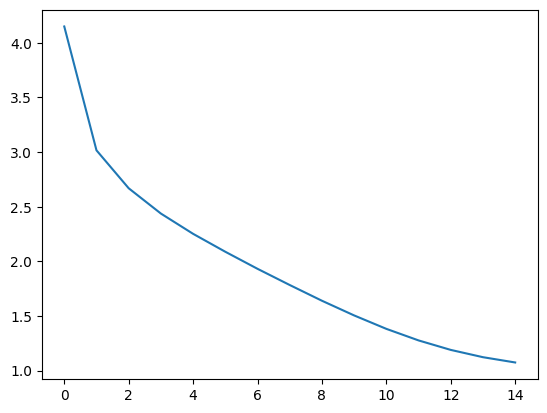

In [ ]:
plt.plot(losses)

In [ ]:
torch.save(model.state_dict(), 'model.pt')

In [ ]:
streamer = Streamer(model, tokenizer)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os
save_dir = '/content/drive/MyDrive/model_weights'
os.makedirs(save_dir, exist_ok=True)
weight_path = os.path.join(save_dir, 'model_weights.pth')
torch.save(model.state_dict(), weight_path)


Mounted at /content/drive


In [ ]:
response = streamer.generate("A girl named Mary walked to the park with her mom", max_len=20)
for token in response:
  print(token, end='')

A girl named Mary walked to the park with her mom. She saw a big slide and wanted to go on it. She ran to the bottom with a slide